# Reading MNIST data files

Jared McBride (10-9-2025, Buena Vista, VA)
---

This notebook reads in the images for the MNIST dataset, puts them into a workable format, and saves then as a pickle file. 

In [3]:
import numpy as np
import struct
from array import array

import random
import pickle
import matplotlib.pyplot as plt

In [4]:
test_images_loc = "/Users/jared.mcbride/Library/CloudStorage/OneDrive-SouthernVirginiaUniversity/Courses/CSC340/MNIST Dataset/t10k-images.idx3-ubyte"

with open(test_images_loc, "rb") as f:
    # > big-endian, I unsigned int
    magic, size, rows, cols = struct.unpack(">IIII", f.read(16)) 

    image_data = array("B",f.read())

FileNotFoundError: [Errno 2] No such file or directory: 't10k-images.idx3-ubyte'

In [3]:
with open("t10k-labels.idx1-ubyte", "rb") as f:
    # > big-endian, I unsigned int
    magic, size = struct.unpack(">II", f.read(8)) 

    y_test = array("B",f.read())

In [4]:
x_test = []
for i in range(size):
    image = np.array(image_data[i*rows*cols:(i+1)*rows*cols])
    image = image.reshape((rows, cols)) / 255.0

    x_test.append(image)

In [5]:
with open("train-images.idx3-ubyte", "rb") as f:
    # > big-endian, I unsigned int
    magic, size, rows, cols = struct.unpack(">IIII", f.read(16)) 

    image_data = array("B",f.read())

In [6]:
with open("train-labels.idx1-ubyte", "rb") as f:
    # > big-endian, I unsigned int
    magic, size = struct.unpack(">II", f.read(8)) 

    y_train = array("B",f.read())

In [7]:
x_train = []
for i in range(size):
    image = np.array(image_data[i*rows*cols:(i+1)*rows*cols])
    image = image.reshape((rows, cols)) / 255.0

    x_train.append(image)

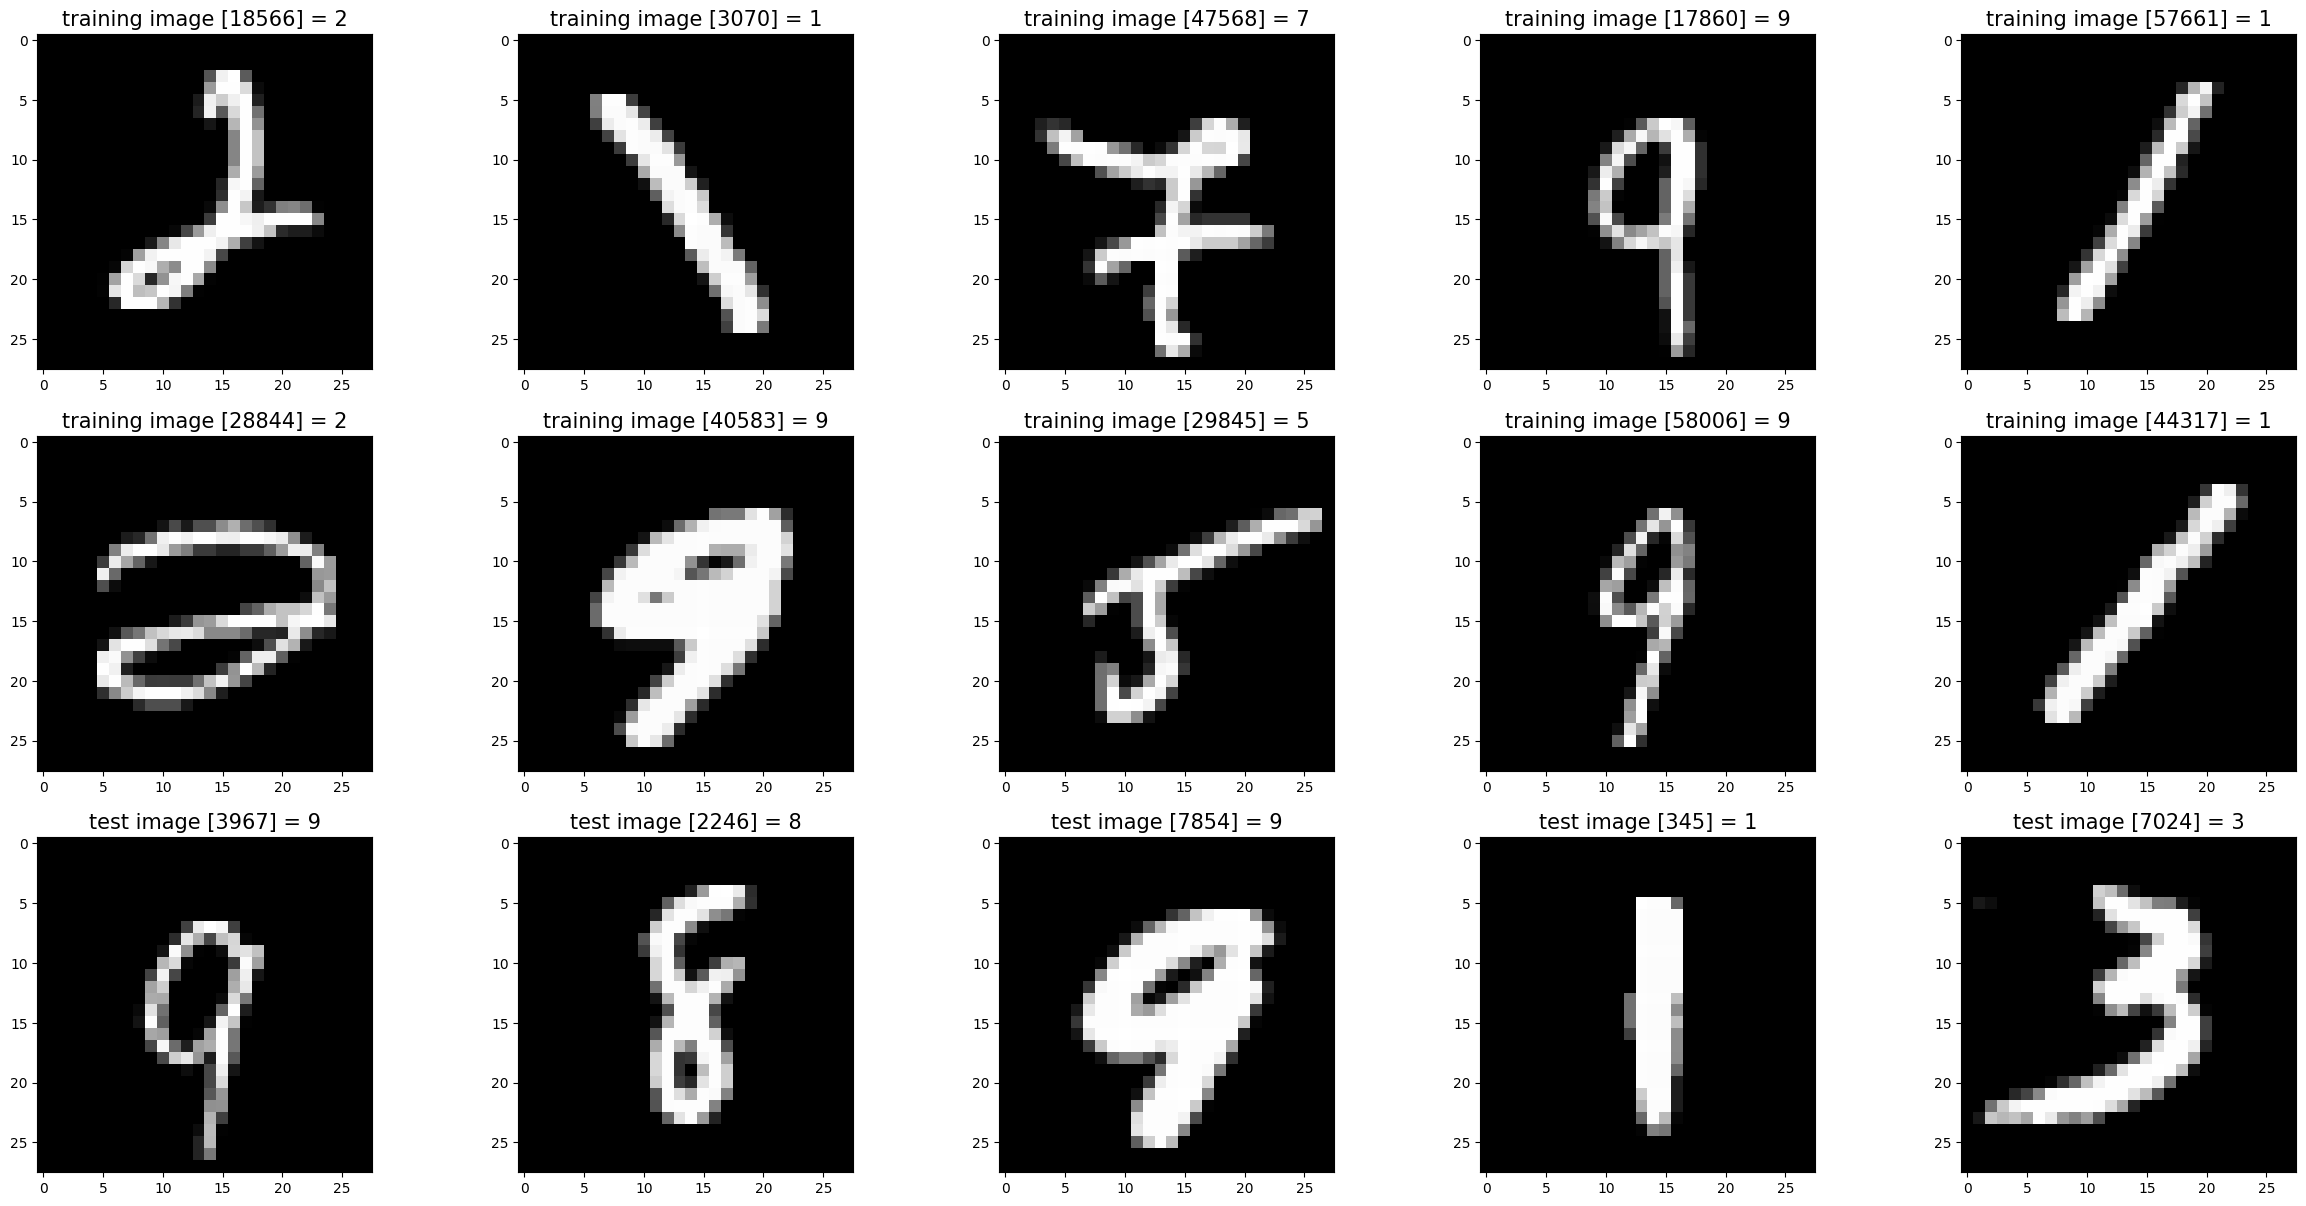

In [11]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [12]:
Data = {"x_train": x_train, "y_train": y_train, "x_test": x_test, "y_test": y_test}

In [13]:
with open("mnist_data.pkl", "wb") as f:
    pickle.dump(Data, f)